<a href="https://colab.research.google.com/github/minjikim0330/ml_project/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8_%EC%8B%9C%EA%B0%81%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

file_path = '/content/drive/MyDrive/머신러닝/instagram_style_fashion_100.csv'

df_excel = pd.read_csv(file_path, encoding='utf-8')

df_excel.head()

,temp,feel_temp,weather,gender,top,bottom,accessory
0,5,3,맑음,여성,니트,청바지,가방
1,7,6,맑음,남성,후드티,슬랙스,숄더백
2,9,9,흐림,여성,자켓,슬랙스,목도리
3,11,12,비,남성,코트,와이드팬츠,우산
4,13,15,맑음,여성,후드티,롱스커트,우산


In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. 데이터 불러오기 및 통합 (Data Pipeline)
# ==========================================

# [1] 깃허브 데이터 불러오기 (직접 수집한 데이터)
github_raw_url = "https://raw.githubusercontent.com/minjikim0330/ml_project/refs/heads/main/weather_clothing_dataset_1.csv"
df_github = pd.read_csv(github_raw_url)

# =====================================================================
# [2] 구글 드라이브 연결 및 CSV 데이터 불러오기 (수정 완료!)
# =====================================================================
from google.colab import drive

# 1. 구글 드라이브와 코랩을 연결합니다
drive.mount('/content/drive')

excel_file_path = '/content/drive/MyDrive/머신러닝/instagram_style_fashion_100.csv'

df_excel = pd.read_csv(excel_file_path, encoding='utf-8') # Changed encoding from 'cp949' to 'utf-8'

print("✅ 드라이브 연결 및 인스타 패션 데이터 로드 완벽 성공!")

# # [3] 크롤링 데이터 구조 맞추기
df_excel['outer'] = '없음'
df_excel['inner'] = '없음'

if 'accessory' in df_github.columns:
    df_github = df_github.rename(columns={'accessory': 'accessories'})
if 'accessory' in df_excel.columns:
    df_excel = df_excel.rename(columns={'accessory': 'accessories'})

columns_order = ['temp', 'feel_temp', 'weather', 'gender', 'outer', 'top', 'bottom', 'inner', 'accessories']

df_github = df_github[columns_order]
df_excel = df_excel[columns_order]

# [4] 두 데이터 하나로 합치기 (위아래로 연결)
df = pd.concat([df_github, df_excel], ignore_index=True)
print(f"데이터 통합 완료! 총 데이터 개수: {len(df)}개")

# ==========================================
# [대안 1 적용] 타겟(Y)을 4단계 두께감 카테고리로 변경
# ==========================================


def assign_outfit_level(temp):
    if temp <= 4:
        return "Level 0: 패딩/헤비아우터 + 목도리 (겨울 한파)"
    elif 5 <= temp <= 16:
        return "Level 1: 코트/자켓 + 니트/셔츠 + 긴바지 (쌀쌀한 환절기)"
    elif 17 <= temp <= 22:
        return "Level 2: 맨투맨/가디건 + 청바지/면바지 (선선한 봄/가을)"
    else:
        return "Level 3: 반팔 + 반바지/얇은바지 (더운 여름)"


df['outfit_level'] = df['temp'].apply(assign_outfit_level)

print("--- 변경된 카테고리별 데이터 분포 ---")
print(df['outfit_level'].value_counts())



le_weather = LabelEncoder()
le_gender = LabelEncoder()
le_level = LabelEncoder() # 새로운 라벨 인코더

df['weather_encoded'] = le_weather.fit_transform(df['weather'].astype(str))
df['gender_encoded'] = le_gender.fit_transform(df['gender'].astype(str))
df['target'] = le_level.fit_transform(df['outfit_level'])

# 입력 특성(X)과 새로운 타겟(y) 분리
X = df[['temp', 'feel_temp', 'weather_encoded', 'gender_encoded']]
y = df['target']


# ==========================================
# 3. 모델 학습 및 평가 (Random Forest)
# ==========================================

# 8:2 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 랜덤포레스트 모델 학습
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# 모델 평가
y_pred = rf_model.predict(X_test)
print("\n=== 새로운 모델 평가 결과 ===")
print(f"테스트 데이터 정확도 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN 정확도:", knn_acc)

from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(random_state=42)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

lgbm_acc = accuracy_score(y_test, lgbm_pred)

print("LightGBM 정확도:", lgbm_acc)


# ==========================================
# 4. 새로운 날씨 데이터로 추천 받기 (테스트)
# ==========================================

def predict_my_outfit(temp, feel_temp, weather, gender):
    try:
        # 입력받은 텍스트를 학습된 인코더로 변환
        w_enc = le_weather.transform([weather])[0]
        g_enc = le_gender.transform([gender])[0]

        # 데이터프레임 형태로 입력값 생성
        input_data = pd.DataFrame([[temp, feel_temp, w_enc, g_enc]],
                                  columns=['temp', 'feel_temp', 'weather_encoded', 'gender_encoded'])

        # 예측 및 역변환 (숫자 -> 옷차림 문자열)
        pred_num = rf_model.predict(input_data)
        pred_str = le_level.inverse_transform(pred_num)[0]

        print(f"\n[추천 결과] {gender}성 / 기온 {temp}도 (체감 {feel_temp}도) / 날씨: {weather}")
        print(f"👉 추천 코디: {pred_str}")

    except ValueError as e:
        print(f"\n[에러] 학습 데이터에 없는 날씨나 성별이 입력되었습니다: {e}")

# 테스트 실행
# predict_my_outfit(temp=15, feel_temp=14, weather='맑음', gender='남')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 드라이브 연결 및 인스타 패션 데이터 로드 완벽 성공!
데이터 통합 완료! 총 데이터 개수: 10100개
--- 변경된 카테고리별 데이터 분포 ---
outfit_level
Level 0: 패딩/헤비아우터 + 목도리 (겨울 한파)           3286
Level 3: 반팔 + 반바지/얇은바지 (더운 여름)            2870
Level 1: 코트/자켓 + 니트/셔츠 + 긴바지 (쌀쌀한 환절기)    2625
Level 2: 맨투맨/가디건 + 청바지/면바지 (선선한 봄/가을)     1319
Name: count, dtype: int64

=== 새로운 모델 평가 결과 ===
테스트 데이터 정확도 (Accuracy): 1.0000
KNN 정확도: 0.9995049504950495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108
[LightGBM] [Info] Number of data points in the train set: 8080, number of used features: 4
[LightGBM] [Info] Start training from score -1.124311
[LightGBM] [Info] Start training from score -1.346978
[LightGBM] [Info] Start training from score -2.035851
[LightGBM] [Info] Start train

In [ ]:
def 추천_옷차림_테스트(현재기온, 체감온도, 날씨, 성별):
    # 입력 데이터를 숫자로 변환
    weather_enc = le_weather.transform([날씨])[0]
    gender_enc = le_gender.transform([성별])[0]

    # 데이터프레임 생성
    input_df = pd.DataFrame([[현재기온, 체감온도, weather_enc, gender_enc]],
                            columns=['temp', 'feel_temp', 'weather_encoded', 'gender_encoded'])

    # 예측
    pred_numeric = rf_model.predict(input_df)
    pred_level = le_level.inverse_transform(pred_numeric)[0]

    print(f"☀️ [입력 날씨] 기온: {현재기온}도 / 체감온도: {체감온도}도 / 날씨: {날씨} / 성별: {성별}")
    print(f"👕 [모델의 추천 결과] {pred_level}")

추천_옷차림_테스트(현재기온=2, 체감온도=-1, 날씨='눈', 성별='남')

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. UI 컨트롤러 만들기
temp_slider = widgets.IntSlider(value=15, min=-10, max=35, step=1, description='현재 기온 (°C):')
feel_slider = widgets.IntSlider(value=14, min=-15, max=40, step=1, description='체감 온도 (°C):')
weather_dropdown = widgets.Dropdown(options=['맑음', '흐림', '비', '눈'], value='맑음', description='날씨:')
gender_radio = widgets.RadioButtons(options=['남', '여'], value='남', description='성별:')
button = widgets.Button(description="👕 옷차림 추천받기", button_style='success')
output = widgets.Output()

# 2. 버튼 클릭 시 예측 결과 출력하는 함수
def on_button_clicked(b):
    with output:
        clear_output()

        # 입력값 가져오기
        t = temp_slider.value
        ft = feel_slider.value
        w = weather_dropdown.value
        g = gender_radio.value

        # 모델 예측 로직 거치기
        w_enc = le_weather.transform([w])[0]
        g_enc = le_gender.transform([g])[0]
        input_data = pd.DataFrame([[t, ft, w_enc, g_enc]], columns=['temp', 'feel_temp', 'weather_encoded', 'gender_encoded'])

        pred_num = rf_model.predict(input_data)
        pred_str = le_level.inverse_transform(pred_num)[0]

        # 결과 화면 출력
        print("="*40)
        print(f" 선택된 날씨: {g}성 / 기온 {t}°C (체감 {ft}°C) / {w}")
        print(f"👉 AI 추천 결과: {pred_str}")
        print("="*40)

button.on_click(on_button_clicked)

# 3. 화면에 UI 배치하기
display(widgets.VBox([temp_slider, feel_slider, weather_dropdown, gender_radio, button, output]))

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np

# 앱 페이지 레이아웃 및 제목 설정
st.set_page_config(page_title="날씨별 옷차림 추천 AI", page_icon="👕", layout="centered")

st.title("🌤️ AI 날씨별 옷차림 추천 서비스")
st.write("오늘의 날씨를 입력하면 머신러닝 모델이 딱 맞는 두께감의 코디를 추천합니다.")

st.markdown("---")

# 왼쪽 사이드바 또는 메인 화면에 입력창 만들기
st.subheader("📊 오늘의 날씨 설정")

col1, col2 = st.columns(2)
with col1:
    temp = st.slider("현재 기온 (°C)", -10, 35, 15)
with col2:
    feel_temp = st.slider("체감 온도 (°C)", -15, 40, 14)

col3, col4 = st.columns(2)
with col3:
    weather = st.selectbox("날씨 정보", ["맑음", "흐림", "비", "눈"])
with col4:
    gender = st.radio("성별", ["남성", "여성"], horizontal=True)

# 모델 예측 시뮬레이션 로직 (우리가 만든 Level 기준 반영)
def assign_outfit_level(t):
    if t <= 4:
         return "Level 0: 패딩/헤비아우터 + 목도리 ❄️", "겨울철 한파 날씨입니다. 두꺼운 다운자켓과 방한 용품으로 체온을 유지하세요."
    elif 5 <= t <= 16:
         return "Level 1: 코트/자켓 + 니트/셔츠 + 긴바지 🍂", " 쌀쌀한 환절기 날씨입니다. 레이어드 룩이나 가벼운 아우터가 좋습니다."
    elif 17 <= t <= 22:
         return "Level 2: 맨투맨/가디건 + 청바지/면바지 🌱", "선선하고 활동하기 좋은 봄/가을 날씨입니다. 가벼운 긴팔 옷차림을 추천합니다."
    else:
         return "Level 3: 반팔 + 반바지/얇은바지 ☀️", "더운 여름 날씨입니다. 통기성이 좋은 얇은 소재의 반팔 옷차림이 적합합니다."

result_title, result_desc = assign_outfit_level(temp)

# 결과 출력 (앱 UI 디자인)
st.markdown("---")
st.subheader("👕 AI 추천 코디")

st.info(f"**{result_title}**")
st.success(f"💬 **스타일링 가이드:** {result_desc}")

# 디테일 아이템 예시 표
st.markdown("#### 🔍 추천 아이템 체크리스트")
if temp <= 4:
    st.checkbox("롱패딩 / 숏패딩", value=True)
    st.checkbox("기모 안감 하의", value=True)
    st.checkbox("목도리 / 장갑", value=True)
elif 5 <= temp <= 16:
    st.checkbox("울 코트 / 가죽 자켓 / 트렌치 코트", value=True)
    st.checkbox("니트 / 가디건 / 셔츠", value=True)
    st.checkbox("슬랙스 / 데님 팬츠", value=True)
elif 17 <= temp <= 22:
    st.checkbox("맨투맨 / 후드티", value=True)
    st.checkbox("면바지 / 청바지", value=True)
else:
    st.checkbox("린넨 반팔티 / 민소매", value=True)
    st.checkbox("반바지 / 얇은 치마", value=True)

In [ ]:
import gradio as gr
import random

def assignment_outfit_app(temp, feel_temp, weather, gender):
    # 1. 기온별 의류 풀(Pool) 설정 - 성별에 따라 하의/아우터를 분리합니다!
    if temp <= 4:
        level = "Level 0: 겨울 한파 스타일링 ❄️"
        guide = "오늘 엄청 추워요! 무조건 따뜻하게 두꺼운 아우터를 입고 나가세요."
        outers = ["롱패딩", "숏패딩", "두꺼운 무스탕"]
        tops = ["기모 후드티", "두꺼운 니트", "목폴라 니트 + 맨투맨"]
        # 겨울엔 남녀 모두 따뜻한 바지 위주로!
        bottoms = ["기모 슬랙스", "기모 스커트", "골덴(코듀로이) 팬츠", "기모 조거팬츠", "기모 트레이닝 바지"]

    elif 5 <= temp <= 16:
        level = "Level 1: 쌀쌀한 환절기 스타일링 🍂"
        guide = "감기 걸리기 딱 좋은 날씨! 가벼운 아우터를 꼭 챙기세요."
        tops = ["셔츠 + 니트 조끼", "탄탄한 맨투맨", "가디건", "셔츠"]

        # 💡 성별에 따른 의류 구별 (Level 1)
        if gender == "남성":
            outers = ["울 코트", "가죽 자켓", "바시티 자켓", "블레이저 자켓"]
            bottoms = ["데님 청바지", "치노 팬츠", "슬랙스"]
        else: # 여성
            outers = ["울 코트", "트렌치 코트", "크롭 가죽자켓", "바시티 자켓","자켓"]
            bottoms = ["A라인 롱스커트", "세미와이드 슬랙스", "부츠컷 청바지", "청바지", "면바지"]

    elif 17 <= temp <= 22:
        level = "Level 2: 선선한 봄/가을 스타일링 🌱"
        guide = "활동하기 딱 좋은 날씨예요. 긴팔이나 얇은 겉옷이면 충분해요."
        tops = ["스트라이프 셔츠", "오버핏 맨투맨", "후드티", "롱 슬리브 티셔츠", "가디건"]

        # 💡 성별에 따른 의류 구별 (Level 2)
        if gender == "남성":
            outers = ["경량 바람막이", "데님 자켓", "얇은 남방(셔츠아우터)", "아우터 없이 단품 가디건"]
            bottoms = ["와이드 슬랙스", "스트레이트 청바지", "조거팬츠"]
        else: # 여성
            outers = ["경량 바람막이", "트위드 자켓", "얇은 오버핏 셔츠", "단품 가디건"]
            bottoms = ["코튼 미니스커트", "플리츠 롱스커트", "와이드 청바지", "부드러운 슬랙스"]

    else:
        level = "Level 3: 더운 여름 한낮 스타일링 ☀️"
        guide = "에어컨 실내외 온도 차이에 주의하시고, 최대한 시원하게 입으세요!"
        tops = ["반팔 티셔츠", "린넨 반팔 셔츠", "피케 카라티", "반팔 니트", "반팔 청남방", "반팔 셔츠"]

        # 💡 성별에 따른 의류 구별 (Level 3)
        if gender == "남성":
            outers = ["아우터 없음 (단품 코디)", "린넨 셔츠(햇빛 가리개용)"]
            bottoms = ["나일론 쿨 팬츠", "버뮤다 반바지", "린넨 와이드 팬츠"]
        else: # 여성
            outers = ["아우터 없음 (단품 코디)", "린넨 셔츠(햇빛 가리개용)"]
            bottoms = ["데님 쇼츠(청반바지)", "린넨 스커트", "얇은 하이웨스트 면바지", "시원한 조거팬츠", "얇은 청바지"]

    # 2. 먕지가 고른 성별과 기온 안에서 딱 하나씩만 랜덤 추출!
    selected_outer = random.choice(outers)
    selected_top = random.choice(tops)
    selected_bottom = random.choice(bottoms)

    match_result = f"🧥 아우터: {selected_outer}\n👕 상의: {selected_top}\n👖 하의: {selected_bottom}"

    # 3. 날씨별 액세서리 조건문
    accessories = "🎒 추천 액세서리: "
    if weather == "비":
        accessories += "장우산 또는 접이식 우산 ☔, 레인부츠"
    elif weather == "눈":
        accessories += "우산 또는 방수 모자 ☃️, 장갑"
    elif weather == "맑음" and temp >= 23:
        accessories += "선글라스 🕶️, 캡모자, 선크림 필수!"
    else:
        accessories += "가벼운 에코백이나 미니 가방 🎒"

    return level, guide, match_result, accessories

# 4. 그라디오 UI 레이아웃 구성
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🌤️ 날씨별 옷차림 코디 추천 서비스")
    gr.Markdown("기온, 날씨, **성별**을 조절하고 버튼을 눌러보세요. 날씨에 맞는 옷차림을 추천해드립니다. ")

    with gr.Row():
        with gr.Column():
            temp_input = gr.Slider(minimum=-10, maximum=35, value=15, step=1, label="현재 기온 (°C)")
            feel_input = gr.Slider(minimum=-15, maximum=40, value=14, step=1, label="체감 온도 (°C)")
            weather_input = gr.Radio(["맑음", "흐림", "비", "눈"], value="맑음", label="날씨 정보")
            gender_input = gr.Radio(["남성", "여성"], value="남성", label="성별")
            submit_btn = gr.Button("🎀 오늘의 코디 추천!", variant="primary")

    gr.Markdown("---")

    with gr.Row():
        with gr.Column():
            output_level = gr.Textbox(label="🎲 추천 코디 레벨", interactive=False)
            output_guide = gr.Textbox(label="💭오늘의 가이드", lines=2, interactive=False)
            output_items = gr.Textbox(label="✨ 오늘 옷차림 추천", lines=2, interactive=False)
            output_acc = gr.Textbox(label="🎈 날씨 맞춤 액세서리", lines=2, interactive=False)

    submit_btn.click(
        fn=assignment_outfit_app,
        inputs=[temp_input, feel_input, weather_input, gender_input],
        outputs=[output_level, output_guide, output_items, output_acc]
    )

demo.launch(share=True)

In [ ]:
!pip install lightgbm

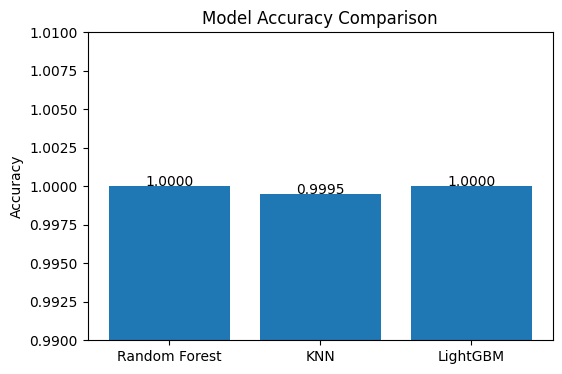

In [8]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'KNN', 'LightGBM']
scores = [1.0, 0.9995049504950495, 1.0]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

for i, v in enumerate(scores):
    plt.text(i, v, f'{v:.4f}', ha='center')

plt.ylim(0.99, 1.01)

plt.show()

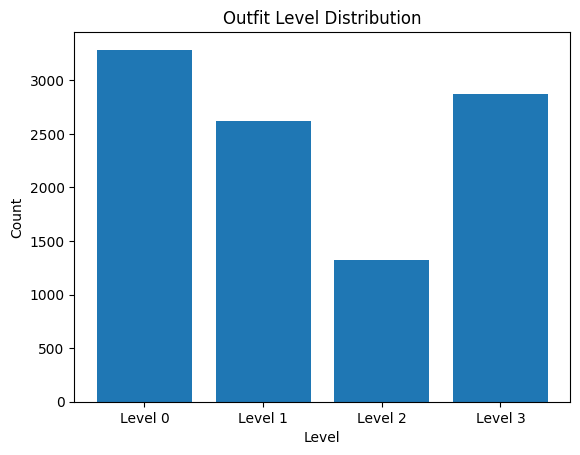

In [9]:
import matplotlib.pyplot as plt

counts = df['outfit_level'].value_counts().sort_index()

plt.bar(
    ['Level 0','Level 1','Level 2','Level 3'],
    counts
)

plt.title('Outfit Level Distribution')
plt.xlabel('Level')
plt.ylabel('Count')

plt.show()